In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation  ##Section might not work depending on notebook I believe?
##Check errors on Github

In [11]:
Nx, Ny = 50, 50  ##This is the grid size, future you can change this
Lx, Ly = 1, 1  ##Domain size
dx, dy = Lx / (Nx - 1), Ly / (Ny - 1)
x = np.linspace(0, Lx, Nx)
y = np.linspace(0, Ly, Ny)
X, Y = np.meshgrid(x, y)

T = 0.5 ##Final time
Nt = 1000  ##Number of timesteps, feel free to change
dt = 0.25 * min(dx, dy)**2 / Nt  ##Number of steps
nu = 0.01  #Viscosity

In [12]:
a1, a2 = 0.5, 0.9
b1, b2 = 0.3, 0.6
## A single pound sign means you can delete / re-add it in my code, two is a permanent comment.
u = 0.2 * a1 * np.sin(np.pi * X) + a2 * np.cos(2 * np.pi * Y)
v = 0.2 * b1 * np.sin(2 * np.pi * X) + b2 * np.cos(np.pi * Y)
#u = 0.2*np.sin(2*np.pi*X)
#v = 0.2*np.cos(2*np.pi*Y)

"""This part is a little bad working unfortunately, need to set max u and v or the code returns a weird u field
   There are a lot less degrees of freedom here than in the 1D code."""

max_u = np.max(np.abs(u))
max_v = np.max(np.abs(v))

max_u = max(max_u, 1e-6)
max_v = max(max_v, 1e-6)

dt_conv = min(dx / max_u, dy / max_v)
dt_diff = min(dx**2, dy**2) / (4 * nu)

dt = 0.2 * min(dt_conv, dt_diff)
Nt = int(T / dt)

print("dt =", dt, "Nt =", Nt)
##Time step matters a lot here unfortunately, I would advise not changing this
##dt directly that is, change u and v to change things

def period(arr):
    temp = arr.copy()

    arr[0, :]  = temp[-2, :]
    arr[-1, :] = temp[1, :]
    arr[:, 0]  = temp[:, -2]
    arr[:, -1] = temp[:, 1]

    return arr

def upwind_x(phi, u, dx):    ##
  phi_x = np.zeros_like(phi)
  phi_x[1: -1,:] = np.where(u[1: -1,:] > 0,
                            (phi[1: -1,:]- phi[0: -2,:]) / dx,
                            (phi[2: ,:] - phi[1: -1,:]) / dx
                            )
  return phi_x

def upwind_y(phi, v, dy):
    phi_y = np.zeros_like(phi)
    phi_y[:, 1:-1] = np.where(
        v[:, 1:-1] > 0,
        (phi[:, 1:-1] - phi[:, 0:-2]) / dy,
        (phi[:, 2:] - phi[:, 1:-1]) / dy
    )
    return phi_y

def laplacian(phi, dx, dy):
    lap = np.zeros_like(phi)
    lap[1:-1,1:-1] = (
        (phi[2:,1:-1] - 2*phi[1:-1,1:-1] + phi[0:-2,1:-1]) / dx**2 +
        (phi[1:-1,2:] - 2*phi[1:-1,1:-1] + phi[1:-1,0:-2]) / dy**2
    )
    return lap

dt = 0.002082465639316951 Nt = 240


In [13]:
frames = []

for n in range(Nt):
  """This part of the code is pretty neat I think.
     The full Burger's system is ut + uux vuy = v(uxx + uyy)
     vt + vux + vvy = v(vxx + vyy), so upwinds and laplacians are needed to compute these uxx and ux """

  if np.any(np.isnan(u)) or np.any(np.isinf(u)):
    print(f"Non evolving grow at {n}")  ##Basically limit approached infinity, not good
    break

  if n % 50 == 0:
    print(f"Step {n}, max(u) = {np.max(u):.4f}")

  if n % 10 == 0:   ##Stores every 10 steps, feel free to change
    frames.append(u.copy())

  u = period(u)
  v = period(v)

  u_x = upwind_x(u, u, dx)
  u_y = upwind_y(u, v, dy)
  v_x = upwind_x(v, u, dx)
  v_y = upwind_y(v, v, dy)

  diff_u = laplacian(u, dx, dy)
  diff_v = laplacian(v, dx, dy)

  u[1: -1, 1: -1] += dt * (- (u[1: -1, 1: -1] * u_x[1: -1,1: -1] +
                             v[1: -1, 1: -1] * u_y[1: -1,1: -1]) +
                          nu * diff_u[1: -1,1: -1])

  ##Quick word of warning, if one is solving a problem and gets a runtime warning, odds are the code wont work
  ##One needs to change the timestep if this happens.

  v[1: -1, 1: -1] += dt * (- (u[1: -1,1: -1] * v_x[1: -1,1: -1] +
                              v[1: -1, 1: -1] * v_y[1: -1, 1: -1]) +
                           nu * diff_v[1: -1, 1: -1])

print(np.max(np.abs(u_x)), np.max(np.abs(u_y)))  ##Expect bounds to be >0, but <1

##Should the code 'explode' go back to where u and v were defined, uncomment the other lines and comment the ones currently used.
##Viscocity could also be changed, but I would advice against that.
##I would recommend also muktiplying u and v by some constant >1, make it smaller.
##SHOULD ALL OF THAT FAIL, manually lower or raise dt, keep it within e-2 to e-4 or 5 maybe.

Step 0, max(u) = 0.9999
Step 50, max(u) = 0.9125
Step 100, max(u) = 0.8380
Step 150, max(u) = 0.7497
Step 200, max(u) = 0.6511
14.198970123498876 1.4144220419817068


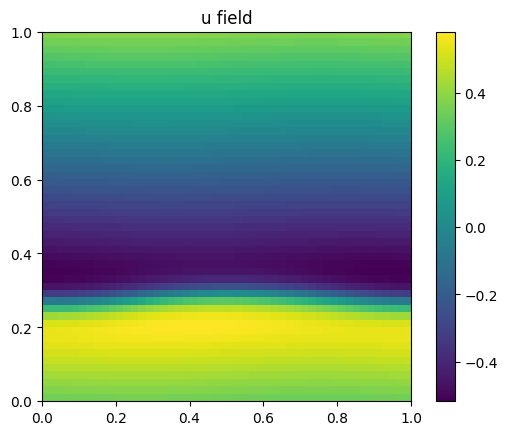

(50, 50) (50, 50) (50, 50)
False False


In [14]:
"""This is a sanity checking section. u field might be boring, sorry if it is"""

plt.figure()
plt.imshow(u, origin='lower', extent=[0,1,0,1])
plt.colorbar()
plt.title("u field")
plt.show()

##Some sanity checks for graphs
print(X.shape, Y.shape, u.shape)
##Should yield (Nx, Ny), so (50, 50) in this case
print(np.isnan(u).any(), np.isinf(u).any())
##Should be false, false.
##Shouldn't be rigid, but it can be

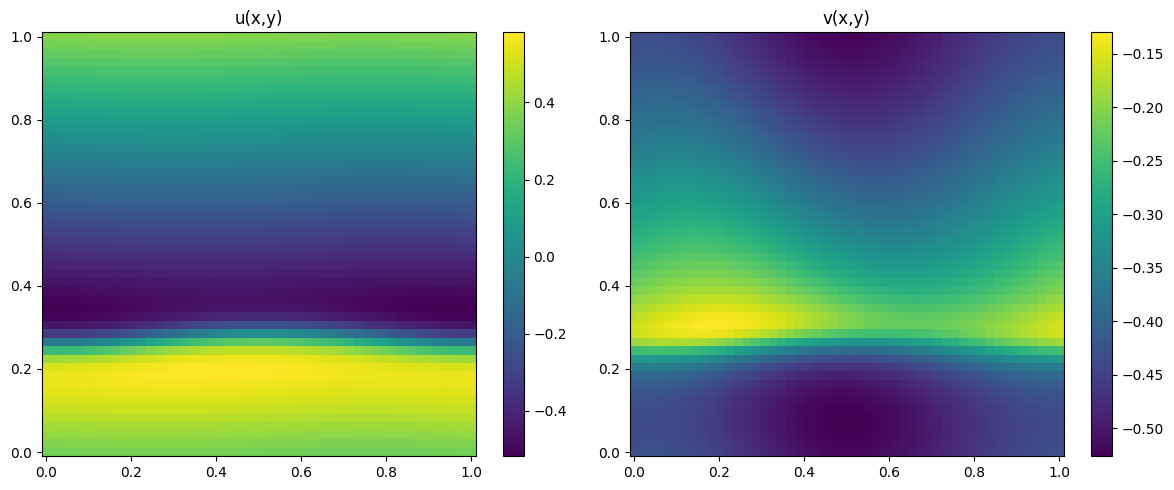

'The graphs might look rigid, this would be a result of the viscocity. I have it lowered to 0.005 rn\n   Change it higher for more rigid, lower if less. 1D is sinosudial and this one isnt, not necissarily right or wrong.'

In [15]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.pcolormesh(X, Y, u, shading='auto')
plt.colorbar()
plt.title("u(x,y)")

plt.subplot(1,2,2)
plt.pcolormesh(X, Y, v, shading='auto')
plt.colorbar()
plt.title("v(x,y)")

plt.tight_layout()
plt.show()

"""The graphs might look rigid, this would be a result of the viscocity. I have it lowered to 0.005 rn
   Change it higher for more rigid, lower if less. 1D is sinosudial and this one isnt, not necissarily right or wrong."""

<function matplotlib.pyplot.show(close=None, block=None)>

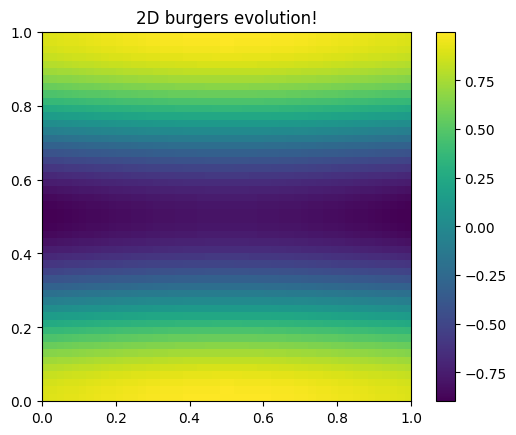

In [16]:
fig, ax = plt.subplots()
cax = ax.imshow(frames[0], origin = 'lower', cmap = 'viridis', extent = [0, 1, 0, 1])
fig.colorbar(cax)

def update(frame):
  cax.set_array(frame)
  return [cax]

anim = animation.FuncAnimation(fig, update, frames = frames, interval = 50, blit = True)
plt.title("2D burgers evolution!")
plt.show
##If figure doesnt work, sorry.